# 3D Convolutional Neural Networks: companion notebook

This notebook accompanies `lecture_notes/20_convnets_1D_3D.pdf`, focusing on the **3D convolution** material. It follows the same philosophy as the 2D and 1D companions: start from small tensor examples, validate shapes and parameter counts, then build compact PyTorch models.

Use it while reading the notes:

- Sections 4.1-4.4: why 3D convolution is useful and how the operation works.
- Sections 4.5-4.6: decomposed 3D convolutions and a practical `nn.Conv3d` architecture.
- Sections 5-6: when 3D is the right choice and what usually goes wrong.


## 0. Setup

The examples are synthetic and local. The visualizations use toy video clips and volumetric tensors.


In [15]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'lecture_notes' / '20_convnets_1D_3D.pdf').exists():
            return path
    return start


PROJECT_ROOT = find_project_root()
print('Project root:', PROJECT_ROOT)


Project root: /Users/ebezerra/ailab/cic1205


## 1. Why 3D convolution exists

Lecture notes, Sections 4.1 and 5.1.

A 3D convolution becomes useful when meaningful patterns extend across **three axes simultaneously**:

- time, height, and width for video;
- depth, height, and width for medical volumes;
- voxelized 3D objects on a grid.

A frame-by-frame 2D CNN can capture appearance, but it cannot directly encode short-range motion or depth continuity.


In [16]:
comparison = [
    ('Conv1d', '(N, C_in, L)', 'audio, time series, token embeddings'),
    ('Conv2d', '(N, C_in, H, W)', 'images and spatial feature maps'),
    ('Conv3d', '(N, C_in, D, H, W)', 'video, CT, MRI, voxel grids'),
]

for name, shape, use_case in comparison:
    print(f'{name:>6}  input={shape:<24} use case={use_case}')


Conv1d  input=(N, C_in, L)             use case=audio, time series, token embeddings
Conv2d  input=(N, C_in, H, W)          use case=images and spatial feature maps
Conv3d  input=(N, C_in, D, H, W)       use case=video, CT, MRI, voxel grids


## 2. The 3D convolution operation

Lecture notes, Section 4.2.

The kernel now slides along depth/time, height, and width. The output-size formula is applied independently to each axis:

$$
D_{out} = \left\lfloor 
rac{D + 2p_d - k_d}{s_d} 
ight
floor + 1,
\quad
H_{out} = \left\lfloor 
rac{H + 2p_h - k_h}{s_h} 
ight
floor + 1,
\quad
W_{out} = \left\lfloor 
rac{W + 2p_w - k_w}{s_w} 
ight
floor + 1
$$


In [17]:
def conv3d_numpy(x, kernel, bias=0.0, stride=(1, 1, 1), padding=(0, 0, 0)):
    x = np.asarray(x, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    sd, sh, sw = stride
    pd, ph, pw = padding

    if any(padding):
        x = np.pad(x, ((pd, pd), (ph, ph), (pw, pw)), mode='constant', constant_values=0)

    kd, kh, kw = kernel.shape
    d, h, w = x.shape
    out_d = (d - kd) // sd + 1
    out_h = (h - kh) // sh + 1
    out_w = (w - kw) // sw + 1
    out = np.zeros((out_d, out_h, out_w), dtype=float)

    for i in range(out_d):
        for j in range(out_h):
            for l in range(out_w):
                d0 = i * sd
                h0 = j * sh
                w0 = l * sw
                window = x[d0:d0 + kd, h0:h0 + kh, w0:w0 + kw]
                out[i, j, l] = np.sum(window * kernel) + bias
    return out


volume = np.arange(1, 1 + 3 * 4 * 4, dtype=float).reshape(3, 4, 4)
kernel = np.array([
    [[1, 0], [0, -1]],
    [[1, 1], [0, 0]],
], dtype=float)
output = conv3d_numpy(volume, kernel)

print('Input shape :', volume.shape)
print('Kernel shape:', kernel.shape)
print('Output shape:', output.shape)
print(output)


Input shape : (3, 4, 4)
Kernel shape: (2, 2, 2)
Output shape: (2, 3, 3)
[[[30. 32. 34.]
  [38. 40. 42.]
  [46. 48. 50.]]

 [[62. 64. 66.]
  [70. 72. 74.]
  [78. 80. 82.]]]


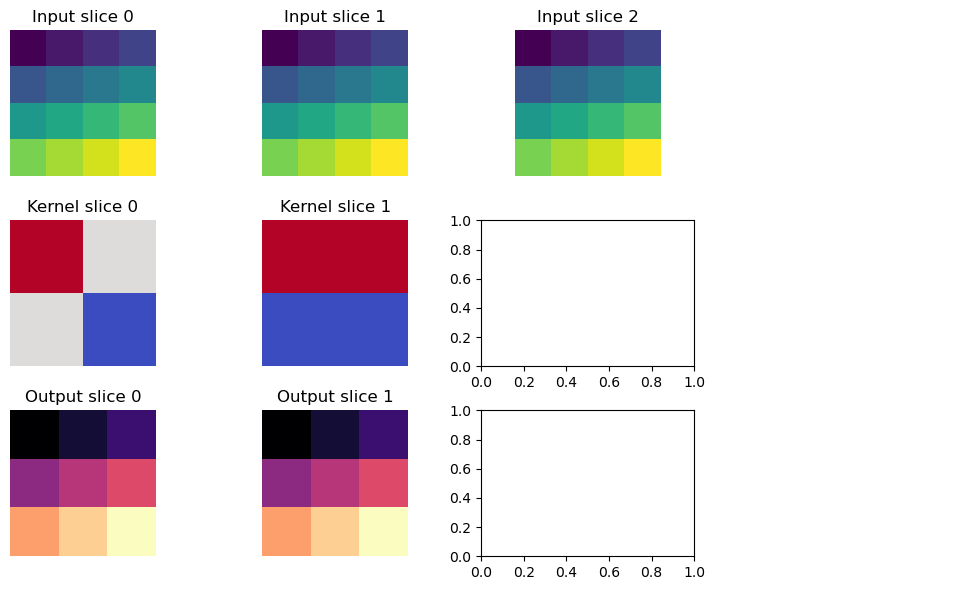

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(10, 6))
for idx in range(volume.shape[0]):
    axes[0, idx].imshow(volume[idx], cmap='viridis')
    axes[0, idx].set_title(f'Input slice {idx}')
    axes[0, idx].axis('off')
for idx in range(kernel.shape[0]):
    axes[1, idx].imshow(kernel[idx], cmap='coolwarm')
    axes[1, idx].set_title(f'Kernel slice {idx}')
    axes[1, idx].axis('off')
for idx in range(output.shape[0]):
    axes[2, idx].imshow(output[idx], cmap='magma')
    axes[2, idx].set_title(f'Output slice {idx}')
    axes[2, idx].axis('off')
for ax in axes[:, -1]:
    ax.axis('off')
plt.tight_layout()


### NumPy and PyTorch compute the same result

PyTorch expects `Conv3d` inputs with shape `(N, C_in, D, H, W)`.


In [19]:
conv = nn.Conv3d(in_channels=1, out_channels=1, kernel_size=(2, 2, 2), stride=1, padding=0, bias=True)

with torch.no_grad():
    conv.weight.copy_(torch.tensor(kernel, dtype=torch.float32).view(1, 1, 2, 2, 2))
    conv.bias.zero_()

torch_input = torch.tensor(volume, dtype=torch.float32).view(1, 1, *volume.shape)
torch_output = conv(torch_input)

print('Input shape: ', tuple(torch_input.shape))
print('Weight shape:', tuple(conv.weight.shape))
print('Output shape:', tuple(torch_output.shape))
np.testing.assert_allclose(output, torch_output.squeeze().detach().numpy())


Input shape:  (1, 1, 3, 4, 4)
Weight shape: (1, 1, 2, 2, 2)
Output shape: (1, 1, 2, 3, 3)


## 3. Parameter counting and computational cost

Lecture notes, Sections 4.3 and 4.4.

A 3D convolutional layer with `C_in` input channels, `C_out` filters, and kernel size `k_d x k_h x k_w` has

$$
C_{out} 	imes (C_{in} 	imes k_d 	imes k_h 	imes k_w + 1)
$$

parameters when bias is enabled.


In [20]:
def conv3d_params(in_channels, out_channels, kernel_size, bias=True):
    kd, kh, kw = kernel_size
    weights = out_channels * in_channels * kd * kh * kw
    return weights + (out_channels if bias else 0)

video = torch.randn(2, 3, 8, 112, 112)
layer = nn.Conv3d(3, 64, kernel_size=(3, 3, 3), padding=1)
out = layer(video)

manual_count = conv3d_params(in_channels=3, out_channels=64, kernel_size=(3, 3, 3), bias=True)
torch_count = sum(p.numel() for p in layer.parameters())
output_positions = int(np.prod(out.shape))

print('Input shape: ', tuple(video.shape))
print('Weight shape:', tuple(layer.weight.shape))
print('Output shape:', tuple(out.shape))
print('Manual parameter count:', manual_count)
print('PyTorch parameter count:', torch_count)
print('Number of output values:', f'{output_positions:,}')


Input shape:  (2, 3, 8, 112, 112)
Weight shape: (64, 3, 3, 3, 3)
Output shape: (2, 64, 8, 112, 112)
Manual parameter count: 5248
PyTorch parameter count: 5248
Number of output values: 12,845,056


### 2D vs 3D parameter counts

Adding a temporal/depth kernel dimension increases both parameter count and compute.


In [21]:
def conv2d_params(in_channels, out_channels, kernel_size, bias=True):
    kh, kw = kernel_size
    weights = out_channels * in_channels * kh * kw
    return weights + (out_channels if bias else 0)

p2d = conv2d_params(3, 64, kernel_size=(3, 3))
p3d = conv3d_params(3, 64, kernel_size=(3, 3, 3))

print('Conv2d parameters:', p2d)
print('Conv3d parameters:', p3d)
print('Ratio Conv3d / Conv2d:', p3d / p2d)


Conv2d parameters: 1792
Conv3d parameters: 5248
Ratio Conv3d / Conv2d: 2.9285714285714284


## 4. A worked video example

Lecture notes, Section 4.4.

Suppose a video clip has shape `(3, 8, 112, 112)` and we apply `Conv3d(3, 64, kernel_size=3, padding=1)`.


In [22]:
def output_size(size, kernel_size, padding=0, stride=1):
    return (size + 2 * padding - kernel_size) // stride + 1

D_out = output_size(8, 3, padding=1, stride=1)
H_out = output_size(112, 3, padding=1, stride=1)
W_out = output_size(112, 3, padding=1, stride=1)

print('Output shape:', (64, D_out, H_out, W_out))
print('Parameter count:', conv3d_params(3, 64, (3, 3, 3)))


Output shape: (64, 8, 112, 112)
Parameter count: 5248


## 5. Decomposed 3D convolutions

Lecture notes, Section 4.5.

Full 3D convolutions are expressive but expensive. Common factorizations separate spatial and temporal processing.


In [23]:
def p3d_params(channels, kernel_size=3):
    spatial = channels * channels * 1 * kernel_size * kernel_size
    temporal = channels * channels * kernel_size * 1 * 1
    return spatial + temporal


def depthwise_separable_3d_params(in_channels, out_channels, kernel_size=3):
    depthwise = in_channels * kernel_size * kernel_size * kernel_size
    pointwise = in_channels * out_channels
    return depthwise + pointwise

channels = 32
full = channels * channels * 3 * 3 * 3
p3d = p3d_params(channels, kernel_size=3)
dw = depthwise_separable_3d_params(channels, channels, kernel_size=3)

print('Full 3D weights:               ', full)
print('Pseudo-3D weights:             ', p3d)
print('Depthwise separable 3D weights:', dw)


Full 3D weights:                27648
Pseudo-3D weights:              12288
Depthwise separable 3D weights: 1888


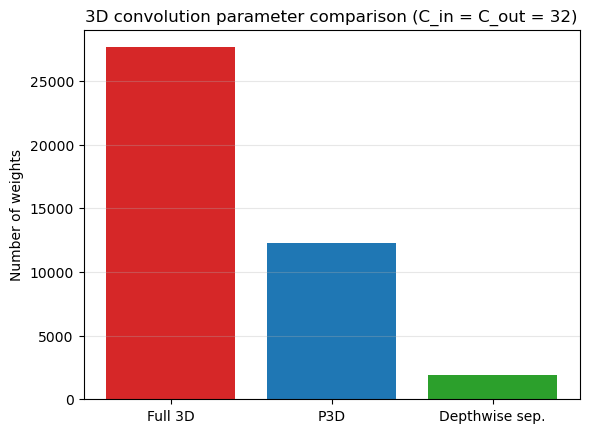

In [24]:
def plot_param_comparison():
    labels = ['Full 3D', 'P3D', 'Depthwise sep.']
    values = [full, p3d, dw]
    plt.bar(labels, values, color=['#d62728', '#1f77b4', '#2ca02c'])
    plt.ylabel('Number of weights')
    plt.title('3D convolution parameter comparison (C_in = C_out = 32)')
    plt.grid(axis='y', alpha=0.3)

plot_param_comparison()


### A minimal (2+1)D block in PyTorch

A `(2+1)D` design applies a spatial convolution `1 x k_h x k_w`, then a temporal convolution `k_d x 1 x 1`, usually with a nonlinearity in between.


In [25]:
class FactorizedSpatiotemporalBlock(nn.Module):
    def __init__(self, in_channels, mid_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, mid_channels, kernel_size=(1, 3, 3), padding=(0, 1, 1), bias=False),
            nn.BatchNorm3d(mid_channels),
            nn.ReLU(),
            nn.Conv3d(mid_channels, out_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


factorized = FactorizedSpatiotemporalBlock(3, 32, 32)
factorized_out = factorized(torch.randn(2, 3, 8, 112, 112))
print('Output shape:', tuple(factorized_out.shape))
print('Parameter count:', sum(p.numel() for p in factorized.parameters()))


Output shape: (2, 32, 8, 112, 112)
Parameter count: 4064


## 6. A compact 3D CNN for video classification

Lecture notes, Section 4.6.

A common design choice in early video layers is **asymmetric pooling**: downsample height and width before aggressively reducing time.


In [26]:
class CNN3D(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),
            nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),
            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),
        )
        self.gap = nn.AdaptiveAvgPool3d(output_size=(1, 1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


model = CNN3D(num_classes=10)
print(model)


CNN3D(
  (features): Sequential(
    (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool3d(output_size=(1, 1, 1))
  (classifier): Sequential(
    (0): Flatte

In [27]:
def trace_shapes_3d(model, x):
    print('input', tuple(x.shape))
    for name, module in model.features.named_children():
        x = module(x)
        print(f'features[{name}] {module.__class__.__name__:>17}: {tuple(x.shape)}')
    x = model.gap(x)
    print(f'gap         {model.gap.__class__.__name__:>17}: {tuple(x.shape)}')
    for name, module in model.classifier.named_children():
        x = module(x)
        print(f'classifier[{name}] {module.__class__.__name__:>10}: {tuple(x.shape)}')
    return x


dummy = torch.randn(4, 3, 16, 112, 112)
logits = trace_shapes_3d(model, dummy)
print('Final logits shape:', tuple(logits.shape))


input (4, 3, 16, 112, 112)
features[0]            Conv3d: (4, 32, 16, 112, 112)
features[1]       BatchNorm3d: (4, 32, 16, 112, 112)
features[2]              ReLU: (4, 32, 16, 112, 112)
features[3]         MaxPool3d: (4, 32, 16, 56, 56)
features[4]            Conv3d: (4, 64, 16, 56, 56)
features[5]       BatchNorm3d: (4, 64, 16, 56, 56)
features[6]              ReLU: (4, 64, 16, 56, 56)
features[7]         MaxPool3d: (4, 64, 8, 28, 28)
features[8]            Conv3d: (4, 128, 8, 28, 28)
features[9]       BatchNorm3d: (4, 128, 8, 28, 28)
features[10]              ReLU: (4, 128, 8, 28, 28)
features[11]         MaxPool3d: (4, 128, 4, 14, 14)
gap         AdaptiveAvgPool3d: (4, 128, 1, 1, 1)
classifier[0]    Flatten: (4, 128)
classifier[1]     Linear: (4, 256)
classifier[2]       ReLU: (4, 256)
classifier[3]    Dropout: (4, 256)
classifier[4]     Linear: (4, 10)
Final logits shape: (4, 10)


### Spatial pooling first, temporal pooling later

This pattern preserves motion information in early layers, when the number of frames is still small.


In [28]:
clip = torch.randn(1, 3, 8, 32, 32)
spatial_pool = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
full_pool = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))

print('Original shape:     ', tuple(clip.shape))
print('Spatial pooling:    ', tuple(spatial_pool(clip).shape))
print('Spatiotemporal pool:', tuple(full_pool(clip).shape))


Original shape:      (1, 3, 8, 32, 32)
Spatial pooling:     (1, 3, 8, 16, 16)
Spatiotemporal pool: (1, 3, 4, 16, 16)


## 7. Training mechanics and debugging

Lecture notes, Sections 5 and 6.


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

clips = torch.randn(2, 3, 16, 112, 112)
labels = torch.tensor([1, 7])

model.train()
optimizer.zero_grad()
logits = model(clips)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()

print('Logits shape:', tuple(logits.shape))
print('One training-step loss:', float(loss.detach()))


/Users/ebezerra/miniconda3/envs/cic1205/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Logits shape: (2, 10)
One training-step loss: 2.1737380027770996


Initial loss: 0.6561417579650879
Final loss:   0.030096981674432755


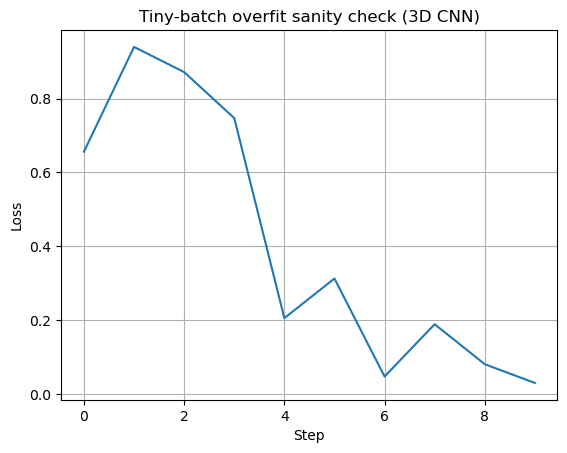

In [30]:
def tiny_batch_overfit_3d(steps=12, lr=5e-3):
    tiny_x = torch.randn(2, 3, 8, 32, 32)
    tiny_y = torch.tensor([0, 1])
    tiny_model = CNN3D(num_classes=2)
    optimizer = torch.optim.Adam(tiny_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses = []
    tiny_model.train()
    for _ in range(steps):
        optimizer.zero_grad()
        loss = criterion(tiny_model(tiny_x), tiny_y)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    return losses

losses = tiny_batch_overfit_3d(steps=10)
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Tiny-batch overfit sanity check (3D CNN)')
plt.grid(True)
print('Initial loss:', losses[0])
print('Final loss:  ', losses[-1])


## 8. Entry-ticket style exercises

1. For a CT scan of shape `(1, 64, 256, 256)`, compute the output shape and parameter count of `Conv3d(1, 32, kernel_size=3, padding=1)`.
2. Compare the first `Conv3d` layer in the notebook with a `Conv2d` layer that uses the same channel counts and spatial kernel size. What is the parameter ratio?
3. Explain why a frame-by-frame 2D CNN misses motion cues that a 3D or `(2+1)D` model can capture.
4. Why is `MaxPool3d(kernel_size=(1, 2, 2))` often preferable to `(2, 2, 2)` in the first video block?


## 9. Key takeaways

- 3D convolution extends the same local-connectivity idea to time/depth plus space.
- In PyTorch, `Conv3d` expects input shape `(N, C, D, H, W)`.
- 3D CNNs are usually parameter-efficient but computationally heavy because the output tensor is large.
- P3D, `(2+1)D`, and depthwise-separable variants reduce cost by factoring spatial and temporal processing.
- Early video models often preserve temporal resolution while downsampling space.
